# uber ride analysis dashboard

## import libraries

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'

## load dataset

In [23]:
data = pd.read_csv("uber_ride_analysis_dataset.csv")

data.head()

,Ride_ID,Date,City,Vehicle_Type,Distance_km,Duration_min,Payment_Method,Surge_Multiplier,Base_Fare,Total_Fare
0,1,2025-01-01 00:00:00,Delhi,Auto,9.59,44,Cash,1.02,115.08,117.38
1,2,2025-01-01 01:00:00,Chennai,Uber XL,16.55,68,Cash,1.43,198.60,284.00
2,3,2025-01-01 02:00:00,Mumbai,Auto,3.95,89,Wallet,1.65,47.40,78.21
3,4,2025-01-01 03:00:00,Chennai,Uber XL,22.33,27,Cash,1.95,267.96,522.52
4,5,2025-01-01 04:00:00,Chennai,Uber Premier,13.07,33,UPI,1.68,156.84,263.49


## Basic Data Inspection

In [24]:
print("Shape of dataset:", data.shape)
print("\nColumns:", data.columns)
print("\nMissing values:\n", data.isnull().sum())

Shape of dataset: (2000, 10)

Columns: Index(['Ride_ID', 'Date', 'City', 'Vehicle_Type', 'Distance_km',
       'Duration_min', 'Payment_Method', 'Surge_Multiplier', 'Base_Fare',
       'Total_Fare'],
      dtype='object')

Missing values:
 Ride_ID             0
Date                0
City                0
Vehicle_Type        0
Distance_km         0
Duration_min        0
Payment_Method      0
Surge_Multiplier    0
Base_Fare           0
Total_Fare          0
dtype: int64


## Convert Date Column

In [25]:
data["Date"] = pd.to_datetime(data["Date"])

data["Month"] = data["Date"].dt.month
data["Hour"] = data["Date"].dt.hour

## KPI Calculations

In [26]:
total_rides = data["Ride_ID"].count()
total_revenue = data["Total_Fare"].sum()
average_fare = data["Total_Fare"].mean()
average_distance = data["Distance_km"].mean()

print("Total Rides:", total_rides)
print("Total Revenue:", round(total_revenue,2))
print("Average Fare:", round(average_fare,2))
print("Average Distance:", round(average_distance,2))

Total Rides: 2000
Total Revenue: 538251.78
Average Fare: 269.13
Average Distance: 12.8


## Monthly Revenue Trend

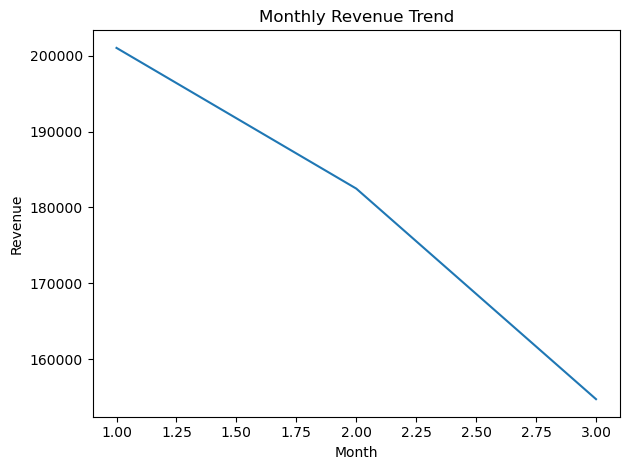

In [17]:
monthly_revenue = data.groupby("Month")["Total_Fare"].sum()

plt.figure()
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Rides by Vehicle Type

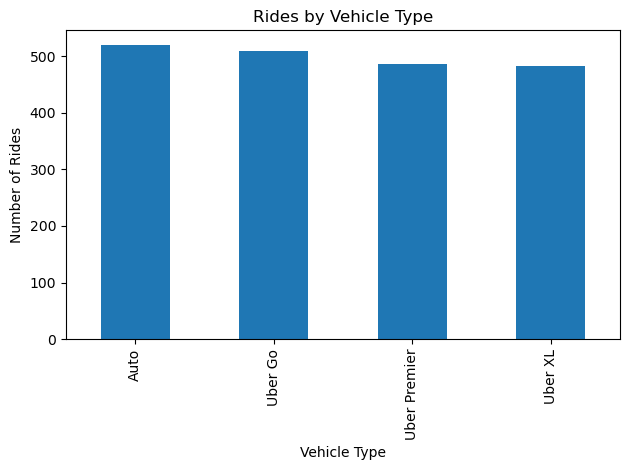

In [18]:
vehicle_counts = data["Vehicle_Type"].value_counts()

plt.figure()
vehicle_counts.plot(kind="bar")
plt.title("Rides by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Rides")
plt.tight_layout()
plt.show()

## Revenue by City

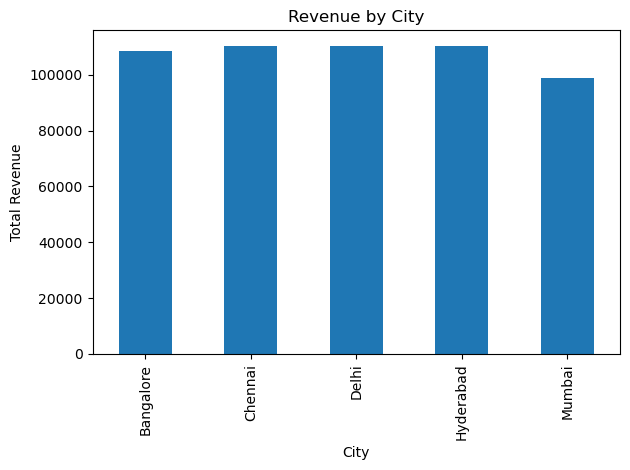

In [19]:
city_revenue = data.groupby("City")["Total_Fare"].sum()

plt.figure()
city_revenue.plot(kind="bar")
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

## Payment Method Distribution

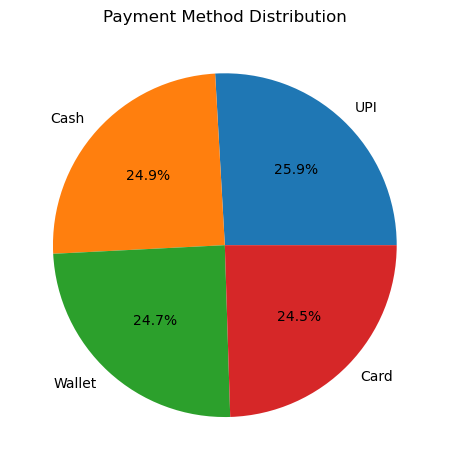

In [20]:
payment_counts = data["Payment_Method"].value_counts()

plt.figure()
payment_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

## peak hour ride analysis

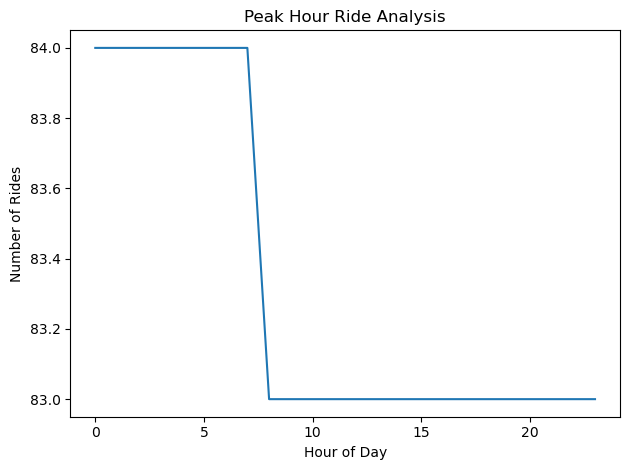

In [21]:
hourly_rides = data.groupby("Hour")["Ride_ID"].count()

plt.figure()
hourly_rides.plot()
plt.title("Peak Hour Ride Analysis")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")
plt.tight_layout()
plt.show()

## Insights

- Highest revenue month identified.
- Most popular vehicle type observed.
- City contributing highest revenue determined.
- UPI/Cash/Card usage trend analyzed.
- Peak ride hours detected for business optimization.